# Plotting DES IAU Named SNIa #

Here we will just explore the residuals of only the SNIa that had IAU names as part of the DES data release. This will involve finding patterns between the SNIa resduals and the Host Galaxy Properties found in BLAST.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import FlatwCDM

In [4]:
CSV_PATH = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_P_S/Pantheon+SH0ES_BLAST_matches_v2.csv"
data = pd.read_csv(CSV_PATH)
data.head()

,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,blast_local_log_mass_50,blast_local_log_sfr_50,blast_local_log_ssfr_50,blast_local_log_age_50,blast_local_mass_surviving_ratio,blast_global_log_mass_50,blast_global_log_sfr_50,blast_global_log_ssfr_50,blast_global_log_age_50,blast_global_mass_surviving_ratio
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,7.027604,-1.237141,-8.107069,2.381033,0.726482,NaN,NaN,NaN,NaN,NaN
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,7.027604,-1.237141,-8.107069,2.381033,0.726482,NaN,NaN,NaN,NaN,NaN
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,8.863532,-1.639513,-10.514228,7.284677,0.577052,8.840373,-1.812903,-10.634429,7.054313,0.580807
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,8.863532,-1.639513,-10.514228,7.284677,0.577052,8.840373,-1.812903,-10.634429,7.054313,0.580807
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,10.100650,-1.030094,-11.141033,8.133928,0.580352,10.212007,-1.893327,-12.107271,8.787093,0.575004


### Computing the Model Distance Modulus

- **Define a cosmology:**  
  `COSMO = FlatwCDM(H0=70, Om0=0.3, w0=-1.0)`  
  This sets up a flat ΛCDM universe with Hubble constant \(H_0 = 70\), matter density \(\Omega_m = 0.3\), and dark energy equation-of-state \(w = -1\).


In [5]:
# Define flat ΛCDM cosmology
COSMO = FlatwCDM(H0=70, Om0=0.3, w0=-1.0)

def mu_LCDM(z):
    """Distance modulus μ(z) for flat ΛCDM."""
    z = np.asarray(z, dtype=float)
    return COSMO.distmod(z).value

# Calculate model distance modulus for each supernova
# Then adds it to the data frame that stores the original .csv datafile
data["mu_model"] = mu_LCDM(data["zHD"])

## Distance Modulus in Pantheon+SH0ES

From the following paper:


The **Pantheon+SH0ES** data set defines the supernova distance modulus, $\mu$, using a modified version of the Tripp relation:

$
\mu \;=\; m_B \;+\; \alpha x_1 \;-\; \beta c \;-\; M \;-\;\delta_{\rm bias} \;-\;\delta_{\rm host},
$

where:

- $m_B$ — observed peak apparent magnitude from the SALT2 light-curve fit.  
- $x_1$ — stretch parameter from SALT2.  
- $c$ — color parameter from SALT2.  
- $\alpha, \beta$ — global nuisance parameters (slope of the stretch–luminosity and color–luminosity relations).  
- $M$ — fiducial absolute magnitude of a standardized SN Ia.  
- $\delta_{\rm bias}$ — bias correction derived from extensive SNANA simulations (accounts for selection effects, measurement biases, etc.).  
- $\delta_{\rm host}$ — host-galaxy mass step correction, applied as a step function at a pivot of $\log_{10}(M_\star/M_\odot)=10$.

In the **Pantheon+ baseline analysis** (BS21/P21 intrinsic scatter models), the host–mass term $\delta_{\rm host}$ is **absorbed into the bias correction** $\delta_{\rm bias}$. As a result, the fitted mass-step amplitude $\gamma$ is statistically consistent with zero (e.g., $\gamma = -0.003 \pm 0.007$ mag for BS21).

Thus, the **publicly released distance moduli** (`MU_SH0ES` in the CSV files) already include bias corrections and effectively have **no explicit ±γ/2 host-mass step applied**.

For alternative scatter models (G10, C11), Pantheon+ reports a nonzero host mass step of $\gamma \simeq 0.05$ mag, pivoted at $\log M_\star = 10$. These variants behave more like the older DES and JLA analyses, where the mass step is applied explicitly.

For alternative scatter models (G10, C11), Pantheon+ reports a nonzero host
mass step of $\gamma \simeq 0.05$ mag, pivoted at $\log M_\star = 10$. These
variants behave more like the older DES and JLA analyses, where the mass step
is applied explicitly.

> **Brout et al. (2022, Pantheon+ Cosmology Constraints)**, Table 2:  
> *“For the BS21 and P21 scatter models, $\gamma$ is consistent with zero
> (−0.003 ± 0.007 and +0.019 ± 0.010). For the G10 and C11 scatter models,
> we find nonzero $\gamma$ values of 0.054 ± 0.007 and 0.053 ± 0.008,
> respectively.”*  
> Pivot mass defined at $\log_{10}(M_\star/M_\odot) = 10$.

📄 [Link to paper on arXiv: 2112.03864](https://arxiv.org/abs/2112.03864)

In [9]:
import numpy as np
import pandas as pd

# --- Inputs from your table ---
# MU_SH0ES       : released (bias-corrected) distance modulus
# HOST_LOGMASS   : log10(M*/Msun); -9.0 means "missing"
# zHD            : heliocentric-independent redshift you’re modeling (already used to make mu_model)

# --- Model choices (match Pantheon+ smoothed step) ---
GAMMA = 0.054   # mag, "what-if" amplitude ~ G10/C11 (Pantheon+ Table 2)
S     = 10.0    # pivot log10(M*/Msun)
TAU   = 0.25    # dex, smoothing width (tau_{M*})

# Grab columns
mu_rel = pd.to_numeric(data["MU_SH0ES"], errors="coerce").to_numpy()
logM   = pd.to_numeric(data["HOST_LOGMASS"], errors="coerce").to_numpy()

# Valid host masses (Pantheon+ uses -9.0 for "no mass")
valid  = logM > -8

# Logistic (smoothed) step centered at S with width TAU
sigmoid = 1.0 / (1.0 + np.exp(-(logM - S) / TAU))

# delta_host = γ * (sigmoid - 0.5)
delta_host = np.zeros_like(mu_rel, dtype=float)
delta_host[valid] = GAMMA * (sigmoid[valid] - 0.5)

# Add the mass step back to the released μ (non-baseline experiment)
mu_withStep = mu_rel + delta_host

# Store results
data["delta_host_added"] = delta_host
data["mu_withMassStep"]  = mu_withStep

# If you already computed a cosmology model mu (e.g., mu_LCDM on zHD):
if "mu_model" in data.columns:
    data["residual_withStep"] = data["mu_withMassStep"] - pd.to_numeric(data["mu_model"], errors="coerce")

# Quick sanity check: measured residual step (high - low) among valid hosts
is_high = (logM >= S)
if "residual_withStep" in data.columns:
    hi = data.loc[valid & is_high,  "residual_withStep"].astype(float)
    lo = data.loc[valid & ~is_high, "residual_withStep"].astype(float)
    if len(hi) > 0 and len(lo) > 0:
        step_measured = hi.mean() - lo.mean()
        print(f"Measured residual step (high - low): {step_measured:.4f} mag  | target ≈ {GAMMA:.4f}")

# Residuals without reintroducing host mass step
data["residual_noStep"] = data["MU_SH0ES"].astype(float) - data["mu_model"].astype(float)

# Residuals with reintroduced host mass step (from the previous block)
data["residual_withStep"] = data["mu_withMassStep"] - data["mu_model"]

# Now you can compare them:
print("Residuals (first few rows):")
print(data[["CID", "residual_noStep", "residual_withStep"]].head())



Measured residual step (high - low): 0.0441 mag  | target ≈ 0.0540
Residuals (first few rows):
             CID  residual_noStep  residual_withStep
0         2011fe         0.406236           0.429861
1         2011fe         0.463436           0.487061
2         2012cg         0.519187           0.502298
3         2012cg         0.540787           0.523898
4  1994DRichmond         0.233710           0.206825


In [10]:
# -------------------
# Feature matrix (BLAST LOCAL + context)
# -------------------
candidate_features = [
    "blast_local_log_mass_50",
    "blast_local_log_sfr_50",
    "blast_local_log_ssfr_50",
    "blast_local_log_age_50",
    "blast_host_redshift",
    "blast_host_EBV_MW",
]

X = data[candidate_features].astype(float)


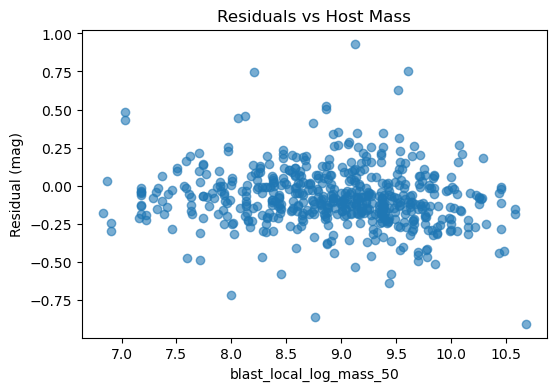

In [12]:
import matplotlib.pyplot as plt

x = data["blast_local_log_mass_50"]   # pick a property
y = data["residual_withStep"]              # your residuals (or "RESID")

plt.figure(figsize=(6,4))
plt.plot(x, y, "o", alpha=0.6)        # simple scatter plot
plt.xlabel("blast_local_log_mass_50")
plt.ylabel("Residual (mag)")
plt.title("Residuals vs Host Mass")
plt.show()

1615


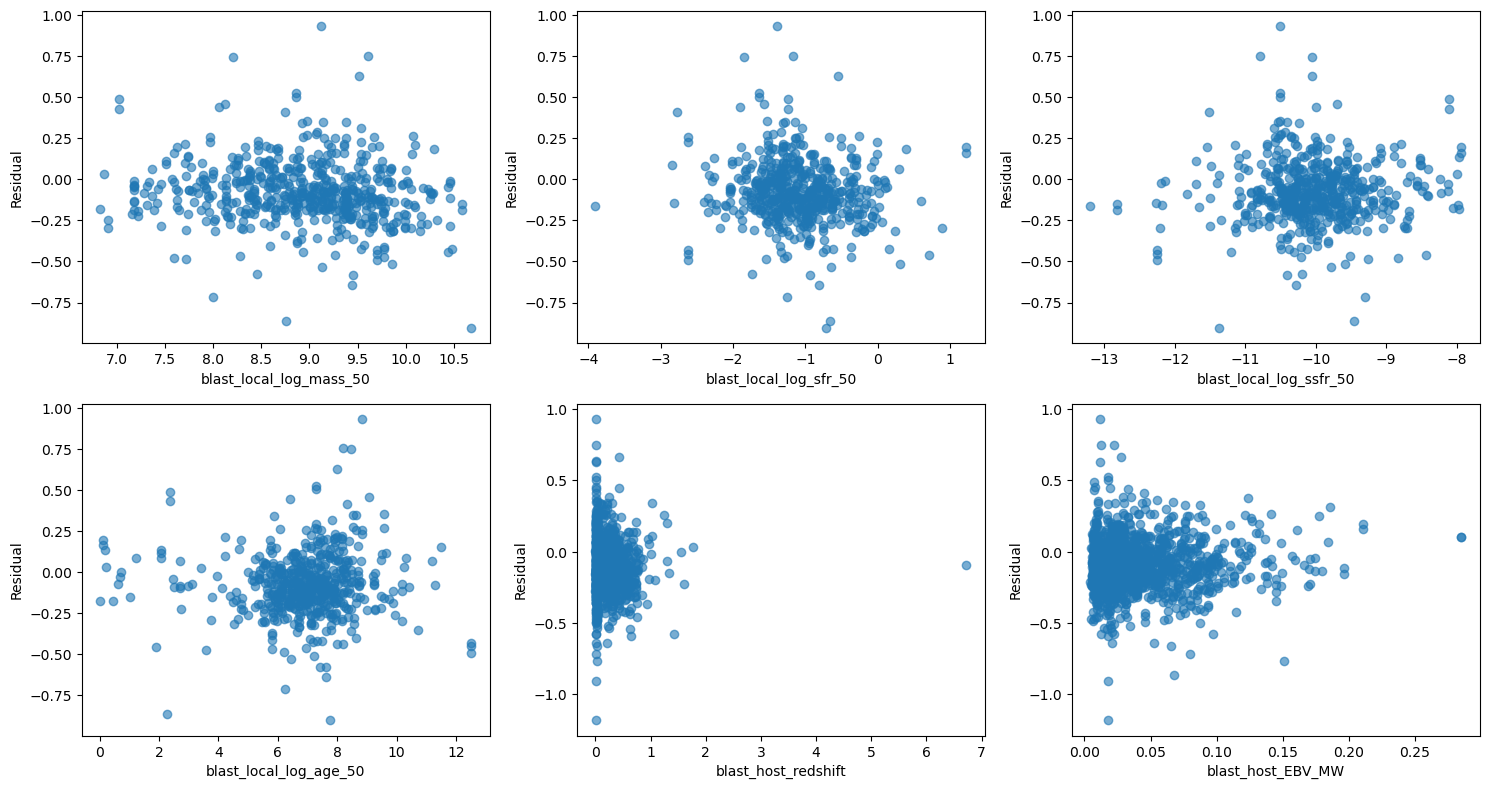

In [14]:
y = data["residual_withStep"]   # or "RESID_noMass"
print(len(y))

# make grid
ncols = 3
nrows = int(np.ceil(len(candidate_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))

for i, prop in enumerate(candidate_features):
    ax = axes.flat[i]
    x = data[prop]
    ax.plot(x, y, "o", alpha=0.6)
    ax.set_xlabel(prop)
    ax.set_ylabel("Residual")

# hide any unused axes
for j in range(i+1, nrows*ncols):
    axes.flat[j].axis("off")

plt.tight_layout()
plt.show()